# Held-Suarez FV Matrix Performance Figures

This notebook reads `performance_analysis/data/matrix_runs.csv` and generates the six recommended performance figures for the FV advection CUDA matrix.

The analysis excludes 16-GPU logs by default because that path is currently tracked as a launcher/infrastructure issue.

In [1]:
from pathlib import Path
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve() if Path.cwd().name == 'performance_analysis' else Path('.').resolve()
DATA_DIR = ROOT / 'performance_analysis' / 'data'
FIG_DIR = ROOT / 'performance_analysis' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

csv_path = DATA_DIR / 'matrix_runs.csv'
if not csv_path.exists():
    subprocess.check_call(['python3', str(ROOT / 'performance_analysis' / 'parse_matrix_logs.py')], cwd=ROOT)

df = pd.read_csv(csv_path)
df['days'] = df['days'].astype(int)
df['completed'] = df['completed'].astype(bool)
completed = df[df['status'].eq('complete')].copy()

res_order = ['T42L25', 'T85L25', 'T170L25', 'T340L25']
day_order = [30, 60, 90, 120]
config_order = ['fortran_16cpu', 'fv_cuda_a_grid_1gpu', 'fv_cuda_a_grid_4gpu']
config_label = {
    'fortran_16cpu': 'Fortran 16 CPU',
    'fv_cuda_a_grid_1gpu': 'FV CUDA 1 GPU',
    'fv_cuda_a_grid_4gpu': 'FV CUDA 4 GPU',
}

df[['resolution','days','config','status','mpp_tmax_s','fv_total_s','outlier_note']].sort_values(['resolution','days','config']).head(40)

,resolution,days,config,status,mpp_tmax_s,fv_total_s,outlier_note
24,T170L25,30,fortran_16cpu,complete,2259.014377,NaN,NaN
25,T170L25,30,fv_cuda_a_grid_1gpu,complete,2349.298236,68.931679,NaN
26,T170L25,30,fv_cuda_a_grid_4gpu,complete,11294.293419,12.425838,completed but performance outlier
27,T170L25,60,fortran_16cpu,complete,4535.960443,NaN,NaN
28,T170L25,60,fv_cuda_a_grid_1gpu,complete,4733.146763,139.122891,NaN
29,T170L25,60,fv_cuda_a_grid_4gpu,partial_time_limit,NaN,NaN,NaN
30,T170L25,90,fortran_16cpu,complete,6641.084748,NaN,NaN
31,T170L25,90,fv_cuda_a_grid_1gpu,complete,7105.579313,199.037069,NaN
0,T42L25,30,fortran_16cpu,complete,24.164602,NaN,NaN
1,T42L25,30,fv_cuda_a_grid_1gpu,complete,48.609280,20.572960,NaN


## Helpers

In [2]:
def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    print('wrote', path)

def heatmap(ax, matrix, title, cmap='viridis', fmt='.1f'):
    values = matrix.to_numpy(dtype=float)
    im = ax.imshow(values, cmap=cmap, aspect='auto')
    ax.set_title(title)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if np.isfinite(values[i, j]):
                ax.text(j, i, format(values[i, j], fmt), ha='center', va='center', color='white', fontsize=8)
            else:
                ax.text(j, i, 'NA', ha='center', va='center', color='black', fontsize=8)
    return im

## Figure 1: Completion Matrix

wrote /panfs/ccds02/nobackup/people/jli30/workspace/GFDL_atmos_cubed_sphere/performance_analysis/figures/figure_1_completion_matrix.png


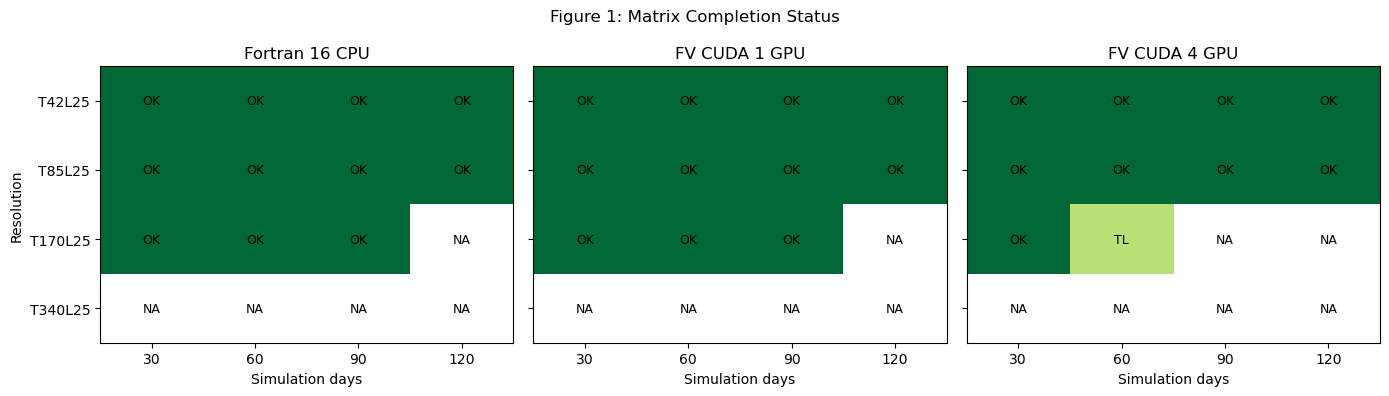

In [3]:
status_score = {'missing': 0, 'failed_or_started': 1, 'partial_no_total': 2, 'partial_time_limit': 2, 'complete': 3}
fig, axes = plt.subplots(1, len(config_order), figsize=(14, 4), sharey=True)
for ax, config in zip(axes, config_order):
    sub = df[df['config'].eq(config)].copy()
    grid = pd.DataFrame(index=res_order, columns=day_order, data=np.nan)
    labels = pd.DataFrame(index=res_order, columns=day_order, data='missing')
    for _, row in sub.iterrows():
        grid.loc[row['resolution'], row['days']] = status_score.get(row['status'], np.nan)
        labels.loc[row['resolution'], row['days']] = row['status']
    im = ax.imshow(grid.to_numpy(dtype=float), cmap='RdYlGn', vmin=0, vmax=3, aspect='auto')
    ax.set_title(config_label[config])
    ax.set_xticks(range(len(day_order)))
    ax.set_xticklabels(day_order)
    ax.set_yticks(range(len(res_order)))
    ax.set_yticklabels(res_order)
    ax.set_xlabel('Simulation days')
    for i, res in enumerate(res_order):
        for j, days in enumerate(day_order):
            label = labels.loc[res, days]
            short = {'complete': 'OK', 'missing': 'NA', 'partial_time_limit': 'TL', 'partial_no_total': 'P', 'failed_or_started': 'F'}.get(label, label)
            ax.text(j, i, short, ha='center', va='center', fontsize=9)
axes[0].set_ylabel('Resolution')
fig.suptitle('Figure 1: Matrix Completion Status')
savefig('figure_1_completion_matrix.png')
plt.show()

## Figure 2: MPP Runtime Heatmaps

/explore/nobackup/people/jli30/.nccstmp/ipykernel_2238258/182711313.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


wrote /panfs/ccds02/nobackup/people/jli30/workspace/GFDL_atmos_cubed_sphere/performance_analysis/figures/figure_2_runtime_heatmaps.png


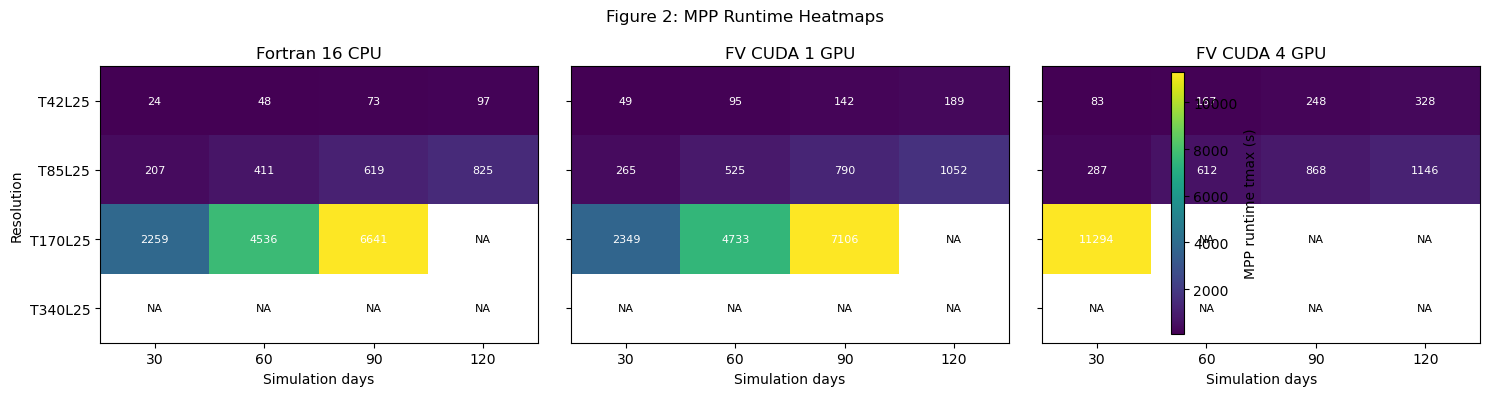

In [4]:
fig, axes = plt.subplots(1, len(config_order), figsize=(15, 4), sharey=True)
for ax, config in zip(axes, config_order):
    sub = completed[completed['config'].eq(config)]
    mat = sub.pivot_table(index='resolution', columns='days', values='mpp_tmax_s', aggfunc='max').reindex(index=res_order, columns=day_order)
    im = heatmap(ax, mat, config_label[config], fmt='.0f')
    ax.set_xlabel('Simulation days')
axes[0].set_ylabel('Resolution')
fig.colorbar(im, ax=axes, shrink=0.85, label='MPP runtime tmax (s)')
fig.suptitle('Figure 2: MPP Runtime Heatmaps')
savefig('figure_2_runtime_heatmaps.png')
plt.show()

## Figure 3: Speedup vs Fortran Heatmaps

/explore/nobackup/people/jli30/.nccstmp/ipykernel_2238258/182711313.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


wrote /panfs/ccds02/nobackup/people/jli30/workspace/GFDL_atmos_cubed_sphere/performance_analysis/figures/figure_3_speedup_vs_fortran_heatmaps.png


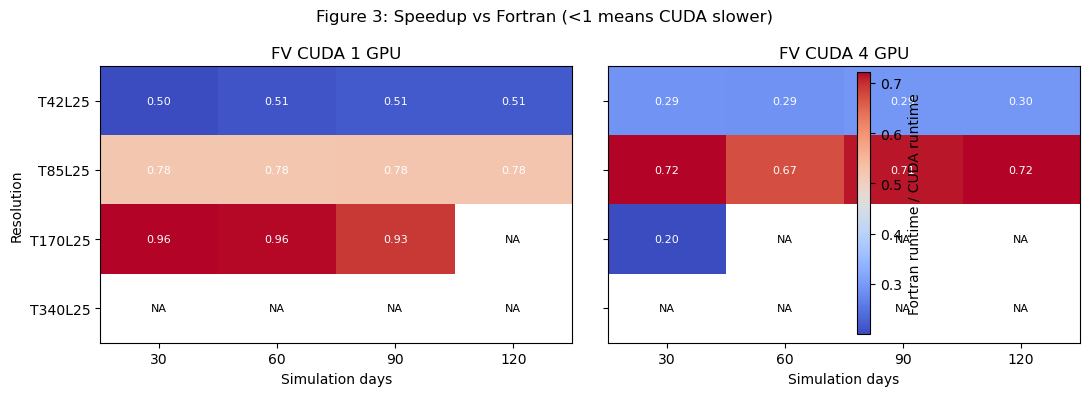

In [5]:
base = completed[completed['config'].eq('fortran_16cpu')][['resolution','days','mpp_tmax_s']].rename(columns={'mpp_tmax_s':'fortran_mpp_tmax_s'})
speed = completed[completed['config'].isin(['fv_cuda_a_grid_1gpu','fv_cuda_a_grid_4gpu'])].merge(base, on=['resolution','days'], how='left')
speed['speedup_vs_fortran'] = speed['fortran_mpp_tmax_s'] / speed['mpp_tmax_s']

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, config in zip(axes, ['fv_cuda_a_grid_1gpu', 'fv_cuda_a_grid_4gpu']):
    mat = speed[speed['config'].eq(config)].pivot_table(index='resolution', columns='days', values='speedup_vs_fortran', aggfunc='max').reindex(index=res_order, columns=day_order)
    im = heatmap(ax, mat, config_label[config], cmap='coolwarm', fmt='.2f')
    ax.set_xlabel('Simulation days')
axes[0].set_ylabel('Resolution')
fig.colorbar(im, ax=axes, shrink=0.85, label='Fortran runtime / CUDA runtime')
fig.suptitle('Figure 3: Speedup vs Fortran (<1 means CUDA slower)')
savefig('figure_3_speedup_vs_fortran_heatmaps.png')
plt.show()

## Figure 4: Runtime Per Simulated Day

wrote /panfs/ccds02/nobackup/people/jli30/workspace/GFDL_atmos_cubed_sphere/performance_analysis/figures/figure_4_runtime_per_day.png


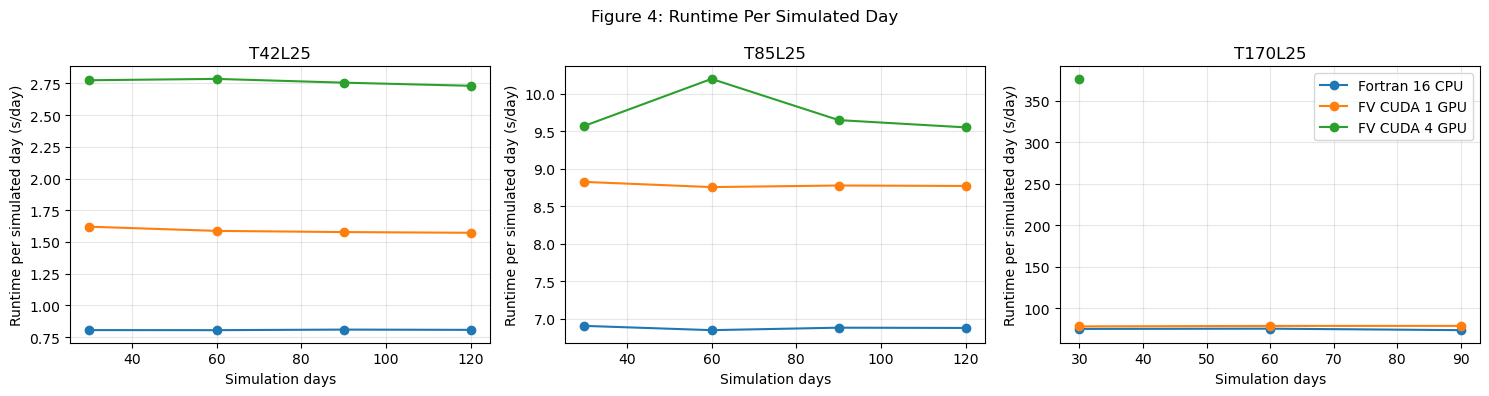

In [6]:
plot_res = ['T42L25', 'T85L25', 'T170L25']
fig, axes = plt.subplots(1, len(plot_res), figsize=(15, 4), sharey=False)
for ax, res in zip(axes, plot_res):
    sub = completed[completed['resolution'].eq(res)]
    for config in config_order:
        line = sub[sub['config'].eq(config)].sort_values('days')
        if line.empty:
            continue
        ax.plot(line['days'], line['runtime_per_day_s'], marker='o', label=config_label[config])
    ax.set_title(res)
    ax.set_xlabel('Simulation days')
    ax.set_ylabel('Runtime per simulated day (s/day)')
    ax.grid(True, alpha=0.3)
axes[-1].legend(loc='best')
fig.suptitle('Figure 4: Runtime Per Simulated Day')
savefig('figure_4_runtime_per_day.png')
plt.show()

## Figure 5: CUDA Phase Stacked Bars

wrote /panfs/ccds02/nobackup/people/jli30/workspace/GFDL_atmos_cubed_sphere/performance_analysis/figures/figure_5_cuda_phase_stacked_fv_cuda_a_grid_1gpu.png


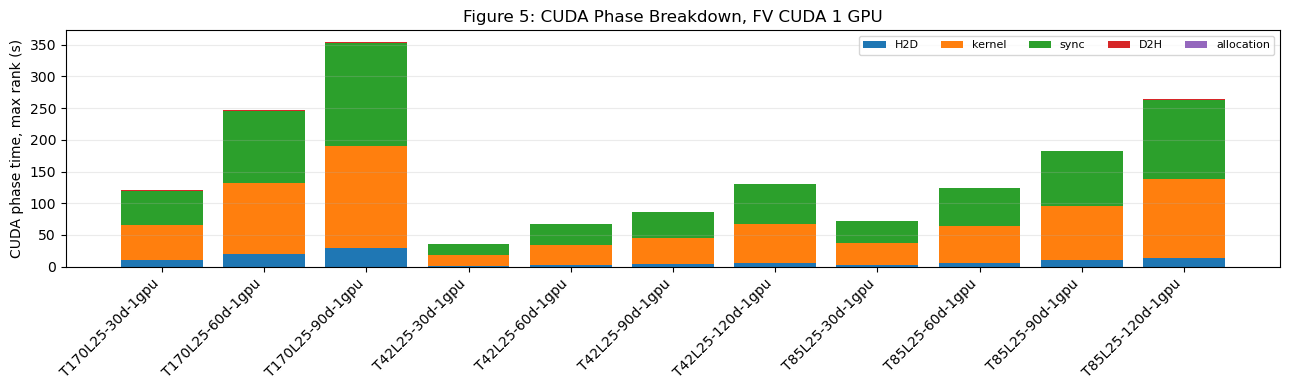

wrote /panfs/ccds02/nobackup/people/jli30/workspace/GFDL_atmos_cubed_sphere/performance_analysis/figures/figure_5_cuda_phase_stacked_fv_cuda_a_grid_4gpu.png


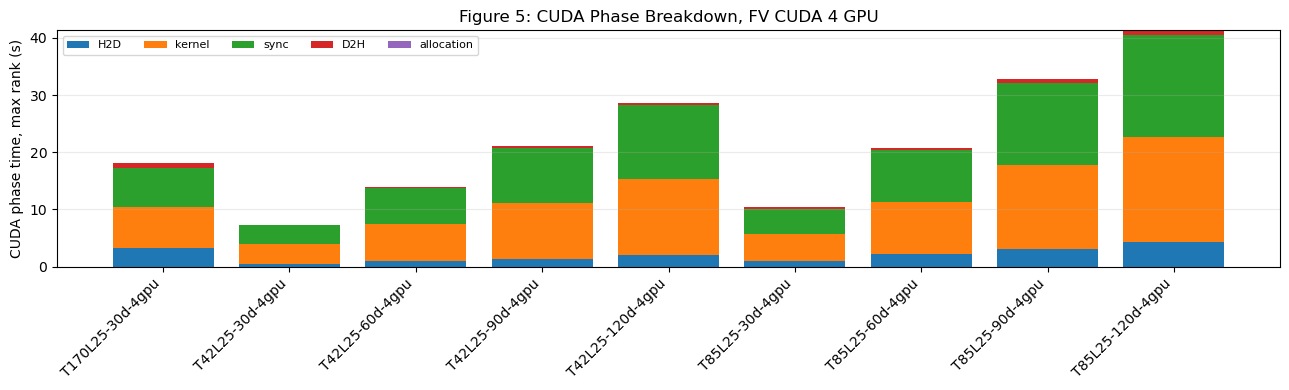

In [7]:
cuda = completed[completed['config'].isin(['fv_cuda_a_grid_1gpu','fv_cuda_a_grid_4gpu'])].copy()
cuda = cuda[cuda['fv_total_s'].notna()]
cuda['case'] = cuda['resolution'] + '-' + cuda['days'].astype(str) + 'd-' + cuda['config'].str.replace('fv_cuda_a_grid_', '', regex=False)
phase_cols = ['fv_h2d_s', 'fv_kernel_s', 'fv_sync_s', 'fv_d2h_s', 'fv_allocation_s']
phase_labels = ['H2D', 'kernel', 'sync', 'D2H', 'allocation']

for config in ['fv_cuda_a_grid_1gpu', 'fv_cuda_a_grid_4gpu']:
    sub = cuda[cuda['config'].eq(config)].sort_values(['resolution','days'])
    fig, ax = plt.subplots(figsize=(13, 4))
    bottom = np.zeros(len(sub))
    x = np.arange(len(sub))
    for col, label in zip(phase_cols, phase_labels):
        vals = sub[col].fillna(0).to_numpy(dtype=float)
        ax.bar(x, vals, bottom=bottom, label=label)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(sub['case'], rotation=45, ha='right')
    ax.set_ylabel('CUDA phase time, max rank (s)')
    ax.set_title(f'Figure 5: CUDA Phase Breakdown, {config_label[config]}')
    ax.legend(ncols=5, fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    savefig(f'figure_5_cuda_phase_stacked_{config}.png')
    plt.show()

## Figure 6: Resolution Scaling, 30-Day Runs

wrote /panfs/ccds02/nobackup/people/jli30/workspace/GFDL_atmos_cubed_sphere/performance_analysis/figures/figure_6_resolution_scaling_30day.png


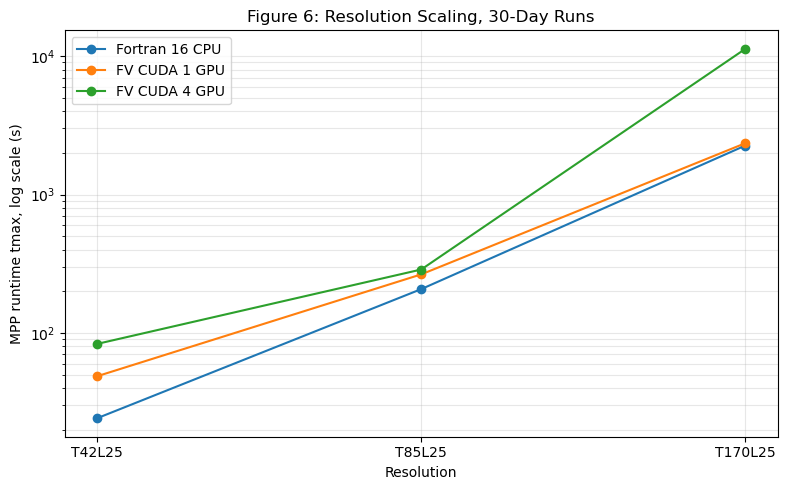

In [8]:
sub = completed[completed['days'].eq(30)].copy()
sub['res_idx'] = sub['resolution'].map({res: i for i, res in enumerate(res_order)})

fig, ax = plt.subplots(figsize=(8, 5))
for config in config_order:
    line = sub[sub['config'].eq(config)].sort_values('res_idx')
    if line.empty:
        continue
    ax.plot(line['resolution'], line['mpp_tmax_s'], marker='o', label=config_label[config])
ax.set_yscale('log')
ax.set_xlabel('Resolution')
ax.set_ylabel('MPP runtime tmax, log scale (s)')
ax.set_title('Figure 6: Resolution Scaling, 30-Day Runs')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
savefig('figure_6_resolution_scaling_30day.png')
plt.show()